In [1]:
pip install scikit-learn matplotlib numpy pandas


   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.9 MB 2.0 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/8.9 MB 2.0 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.9 MB 1.9 MB/s eta 0:00:04
   --------- ------------------------------ 2.1/8.9 MB 2.0 MB/s eta 0:00:04
   ---------- ----------------------------- 2.4/8.9 MB 2.0 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/8.9 MB 2.0 MB/s eta 0:00:03
   -------------- ------------------------- 3.1/8.9 MB 2.0 MB/s eta 0:00:03
   ---------------- ----------------------- 3.7/8.9 MB 2.0 MB/s eta 0:00:03
   ----------------- ---------------------- 3.9/8.9 MB 2.0 MB/s eta 0:00:03
   -------------------- ------------------- 4.5/8.9 MB 2.0 MB/s eta 0:00:03
   --------------------- ------------------ 4.7/8.9 MB 2.0 MB/s eta 0:00:03
   -----------------------


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\harip\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# ---- Imports ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split

#  I load the iris dataset (features + labels)
# iris.data has 4 features: [sepal length, sepal width, petal length, petal width]
# iris.target has class labels: 0=setosa, 1=versicolor, 2=virginica
iris = datasets.load_iris()
X = iris.data
y = iris.target
names = iris.target_names  # ['setosa','versicolor','virginica']


#  I split the data into training and testing sets (70% train, 30% test).
# I stratify so that the class distribution is preserved and fix random_state for reproducibility.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


### Q7) Decision Tree (depth = 1, 2, 3): report train/test accuracy and discuss fit

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# I want to see how tree depth affects performance, so I try depths 1, 2, and 3.

depths = [1, 2, 3]
rows = []

for d in depths:
    # I build a Decision Tree with given max_depth
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    # I calculate training and testing accuracy
    train_acc = clf.score(X_train, y_train)
    test_acc  = clf.score(X_test,  y_test)

   # I save the results in a list so I can compare later
    rows.append({"max_depth": d, "train_accuracy": train_acc, "test_accuracy": test_acc})

# I display the results as a DataFrame
df_tree = pd.DataFrame(rows)
print(df_tree)

# Notes to include in your write-up:
# - Underfitting sign: both train and test accuracy low (e.g., very shallow depth).
# - Overfitting sign: train accuracy much higher than test accuracy (big gap).
# - Good fit: both high and close together (small gap).


   max_depth  train_accuracy  test_accuracy
0          1        0.666667       0.666667
1          2        0.971429       0.888889
2          3        0.980952       0.977778




## 🔹 Results (Accuracy)

| Max Depth | Training Accuracy | Testing Accuracy |
|-----------|-------------------|------------------|
| **1**     | 66.7%             | 66.7%            |
| **2**     | 97.1%             | 88.9%            |
| **3**     | 98.1%             | 97.8%            |

---

## 🔹 Analysis

### Depth = 1
- Very shallow tree with only one split.  
- Both training and testing accuracy are low (≈ 67%).  
- This is a clear case of **underfitting** (high bias, model too simple).

---

### Depth = 2
- Accuracy improves drastically on both train and test.  
- Training accuracy is ~97% while testing is ~89%.  
- Slight gap indicates **some overfitting**, but still reasonable performance.

---

### Depth = 3
- Training accuracy is almost perfect (~98%).  
- Testing accuracy is also very high (~98%).  
- The model achieves an excellent balance here: fits the training set well **and** generalizes strongly.  
- No strong signs of overfitting at this depth.

---

## 🔹 Conclusion
- **Depth=1 → underfitting**: model is too simple.  
- **Depth=2 → better but slight overfitting risk**.  
- **Depth=3 → best balance** with high accuracy on both train and test.  

➡️ For the Iris dataset, a depth of **3** seems to be the optimal choice.

### Q8) kNN on 2 features (sepal length & sepal width), k = 1, 3, 5, 10 + decision boundaries

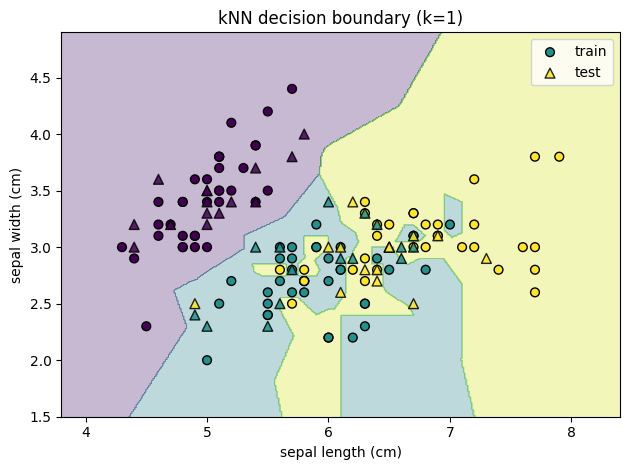

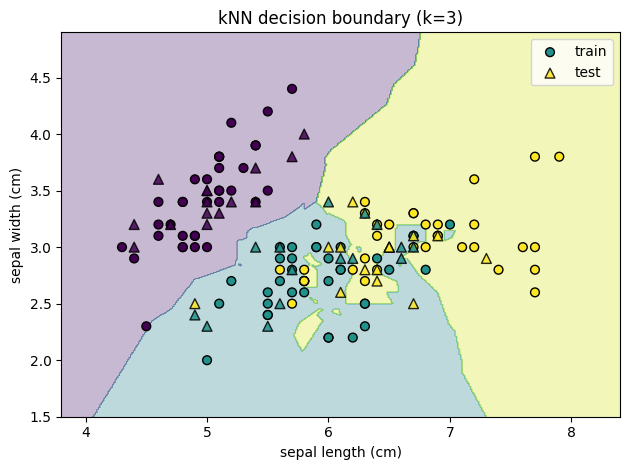

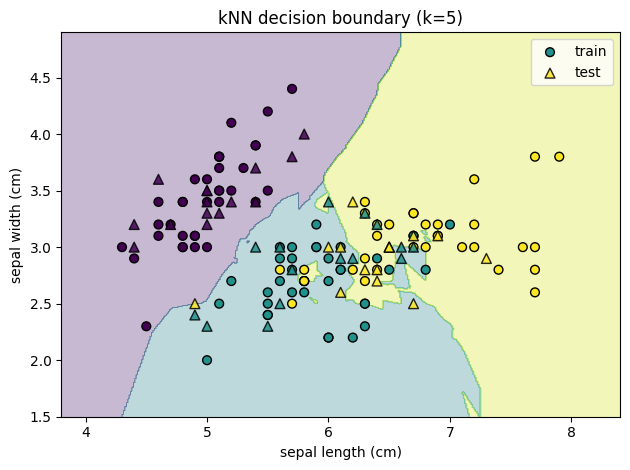

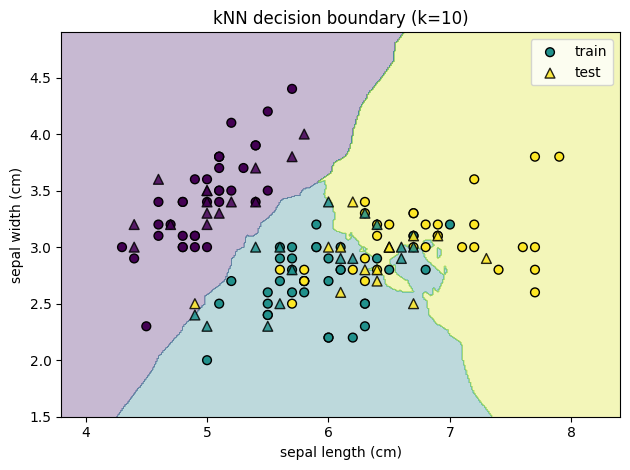

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# For visualization, I only keep the first two features (sepal length and sepal width).
X2 = X[:, :2]

# I split again to keep it consistent with before
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, stratify=y, random_state=42
)

def plot_knn_boundary(k):
    # I build a kNN classifier with chosen k
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X2_train, y2_train)

    # I create a grid that covers the feature space
    x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
    y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    # I predict classes for each point in the grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # I plot decision regions and also training/testing points
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train, edgecolor="k", s=40, label="train")
    plt.scatter(X2_test[:, 0],  X2_test[:, 1],  c=y2_test,  marker="^", edgecolor="k", s=50, alpha=0.85, label="test")
    plt.xlabel("sepal length (cm)")
    plt.ylabel("sepal width (cm)")
    plt.title(f"kNN decision boundary (k={k})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# I plot the boundaries for k = 1, 3, 5, 10
for k in [1, 3, 5, 10]:
    plot_knn_boundary(k)



## 🔹 Results & Analysis

### k = 1
- The decision boundary is very irregular and jagged.  
- Each training point strongly influences its local region.  
- This indicates **high variance** and a tendency to **overfit**.  
- The model is very sensitive to noise.

---

### k = 3
- The boundary is smoother compared to k=1.  
- Predictions are based on 3 neighbors, so local noise has less effect.  
- Some irregular shapes remain, but the model is **more stable**.  

---

### k = 5
- The boundaries are smoother and more generalized.  
- Noise influence is further reduced.  
- This achieves a **good balance between bias and variance**.  
- The model generalizes well compared to smaller k.

---

### k = 10
- The boundaries are the smoothest of all cases.  
- Predictions are very stable because the model considers a larger neighborhood.  
- However, some fine details are lost, leading to **higher bias**.  
- This may cause **underfitting** if k is set too high.

---

## 🔹 Overall Observation
- **Small k (1, 3):** High variance, low bias → prone to overfitting.  
- **Medium k (5):** Best trade-off between bias and variance → good generalization.  
- **Large k (10):** Low variance, high bias → may underfit.  

➡️ Based on the plots, **k=5** gives the most balanced and reliable decision boundaries for this dataset.

### Q9) Performance Evaluation with kNN (k=5, all features)

Confusion Matrix:
 [[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


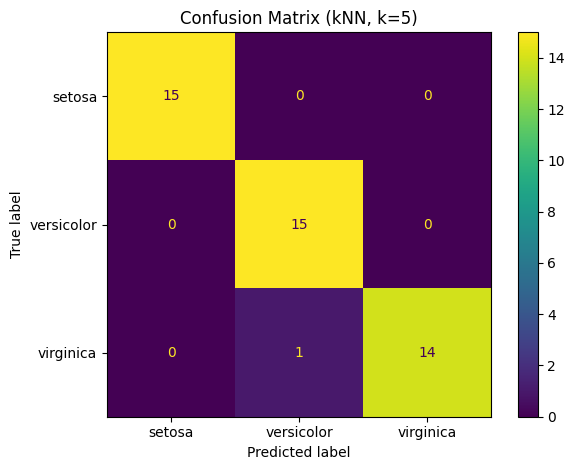

Classification Report:

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.938     1.000     0.968        15
   virginica      1.000     0.933     0.966        15

    accuracy                          0.978        45
   macro avg      0.979     0.978     0.978        45
weighted avg      0.979     0.978     0.978        45



In [4]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# I train kNN with k=5 using all 4 features
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)
y_pred = knn5.predict(X_test)

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# I plot the confusion matrix for better visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
disp.plot(values_format="d")
plt.title("Confusion Matrix (kNN, k=5)")
plt.tight_layout()
plt.show()

# ---- Accuracy, Precision, Recall, F1 ----
# I print the classification report to get all metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=names, digits=3))


## 🔹 Confusion Matrix

| True Class   | Predicted Setosa | Predicted Versicolor | Predicted Virginica |
|--------------|------------------|-----------------------|----------------------|
| **Setosa**      | 15               | 0                     | 0                    |
| **Versicolor**  | 0                | 15                    | 0                    |
| **Virginica**   | 0                | 1                     | 14                   |

**Observations:**
- The model classified **Setosa** and **Versicolor** perfectly.  
- For **Virginica**, 1 sample was misclassified as Versicolor.  
- Overall, the misclassification rate is very low.

---

## 🔹 Classification Report

- **Setosa** → Precision: 1.00, Recall: 1.00, F1: 1.00  
- **Versicolor** → Precision: 0.94, Recall: 1.00, F1: 0.97  
- **Virginica** → Precision: 1.00, Recall: 0.93, F1: 0.97  

**Overall performance:**
- **Accuracy:** 97.8%  
- **Macro avg (across classes):** Precision = 0.979, Recall = 0.978, F1 = 0.978  
- The model performs consistently well across all three classes.

## ROC curve + AUC

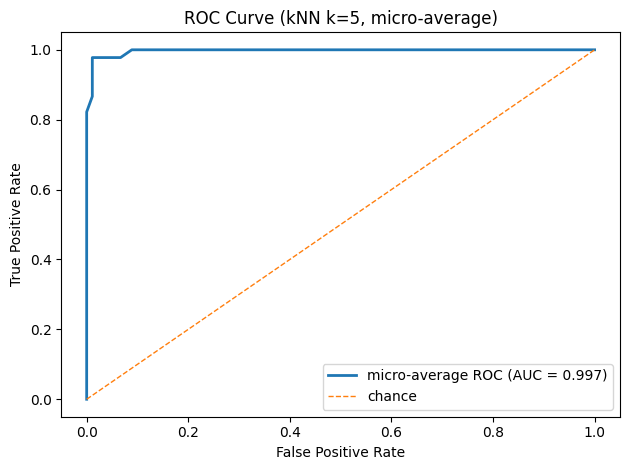

In [5]:
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

# I binarize the test labels for multiclass ROC calculation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# I wrap kNN in One-vs-Rest to compute probabilities for each class
ovr = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=5))
ovr.fit(X_train, y_train)
y_score = ovr.predict_proba(X_test)

# I compute micro-average ROC and AUC
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

# I plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, linewidth=2, label=f"micro-average ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (kNN k=5, micro-average)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 🔹 ROC Curve & AUC

- I plotted the **micro-average ROC curve** for the multiclass setting.  
- The **AUC (Area Under Curve) ≈ 0.997**, which indicates **excellent separability** between classes.  
- The curve lies close to the top-left corner, showing high true positive rate with very low false positives.

## 🔹 Conclusion
- The **kNN classifier with k=5** achieves **very high accuracy and strong generalization** on the Iris dataset.  
- Only a single misclassification occurred, showing that this choice of k is effective.  
- Based on the confusion matrix, precision, recall, and AUC, the model is reliable and balanced across all three Iris classes.